# 02 EDA and Featurization

This notebook summarizes the processed 15-5PH fastener dataset, creates the proof-of-concept target/property figure, and defines the domain-derived feature set used for modeling.

In [2]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Make paths work whether the notebook is run from the repo root or notebooks folder
NOTEBOOK_DIR = Path.cwd()
if NOTEBOOK_DIR.name == "notebooks":
    REPO_ROOT = NOTEBOOK_DIR.parent
else:
    REPO_ROOT = NOTEBOOK_DIR

DATA_DIR = REPO_ROOT / "data"
FIGURE_DIR = REPO_ROOT / "figures"
FIGURE_DIR.mkdir(exist_ok=True)

processed_path = DATA_DIR / "processed_material_database.csv"


## Load processed dataset

In [3]:
df = pd.read_csv(processed_path)

print("Dataset shape:")
print(df.shape)

display(df.head())


Dataset shape:
(6, 42)


,JobNum,Lot_ID,PartNum,TestStage,HeatTreatSequence,AgeTemp_F,AgeTime_hr,Reaged,Mean_OD_in,Mean_ID_in,...,SolutionHard_HBW,Dia_Tensile,Cert_UTS_ksi,Cert_Yield_ksi,Cert_Elong_pct,Cert_RA_pct,AgedHard_HRC,GrainSize,MeanNetArea_in2,MeanShearLoad_lbf
0,F2915-00,16347,115A5260-603,T1,1,1160,4,0,1.349767,0.730267,...,319.0,0.5,199.0,180.0,16.0,56.0,NaN,NaN,1.012049,184271.671558
1,F2915-00,16347,115A5260-603,T1A,2,1180,4,1,1.349583,0.730233,...,319.0,0.5,199.0,180.0,16.0,56.0,NaN,NaN,1.011698,176989.300629
2,F2915-00,16347,115A5260-603,T2,2,1180,4,1,1.349654,0.737531,...,319.0,0.5,199.0,180.0,16.0,56.0,NaN,NaN,1.003436,176800.693623
3,F2916-00,16827,115A5260-603,T1,1,1160,4,0,1.349750,0.730050,...,353.0,0.5,195.0,194.0,17.0,61.0,41.0,NaN,1.012262,185598.445397
4,F2916-00,16827,115A5260-603,T1A,2,1180,4,1,1.349650,0.721283,...,353.0,0.5,195.0,194.0,17.0,61.0,41.0,NaN,1.022043,178736.972067


## Target property summary

The target property is job-level mean double-shear strength in ksi. The dataset is small, so these summaries are used to describe the proof-of-concept data rather than to make strong statistical claims.

In [4]:
target_col = "MeanShear_ksi"

print("Target property: MeanShear_ksi (ksi)")
display(df[target_col].describe())

print("\nAge temperatures:")
display(df["AgeTemp_F"].value_counts().sort_index())

print("\nSpecimen counts by job/test stage:")
display(df[["JobNum", "Lot_ID", "TestStage", "SpecimenCount", "MeanShear_ksi"]])


Target property: MeanShear_ksi (ksi)


count     6.000000
mean     88.840732
std       1.978071
min      87.320294
25%      87.448615
50%      87.784526
75%      90.303609
max      91.675099
Name: MeanShear_ksi, dtype: float64


Age temperatures:


AgeTemp_F
1160    2
1180    4
Name: count, dtype: int64


Specimen counts by job/test stage:


,JobNum,Lot_ID,TestStage,SpecimenCount,MeanShear_ksi
0,F2915-00,16347,T1,6,91.038919
1,F2915-00,16347,T1A,6,87.471372
2,F2915-00,16347,T2,13,88.097680
3,F2916-00,16827,T1,6,91.675099
4,F2916-00,16827,T1A,6,87.441029
5,F2916-00,16827,T2,14,87.320294


## Figure 1: shear strength versus age temperature

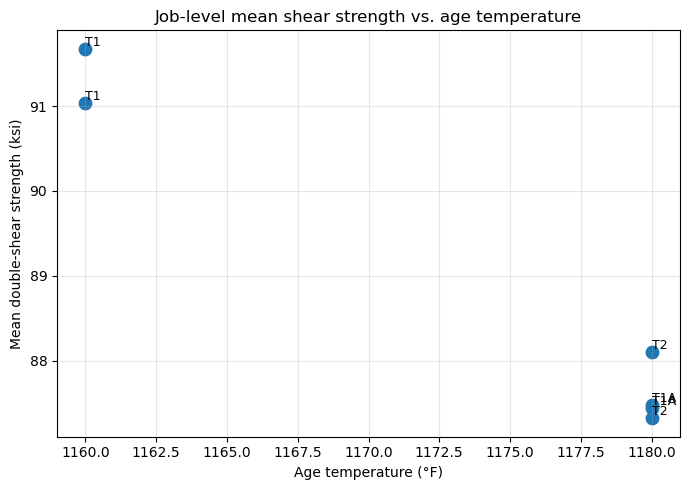

Saved figure to: /Users/SenkoBaby/Desktop/15-5ph-shear-strength-ml/figures/figure1_shear_vs_age_temp.png


In [5]:
plt.figure(figsize=(7, 5))

plt.scatter(
    df["AgeTemp_F"],
    df["MeanShear_ksi"],
    s=80
)

for _, row in df.iterrows():
    label = f'{row["TestStage"]}'
    plt.text(
        row["AgeTemp_F"],
        row["MeanShear_ksi"],
        label,
        fontsize=9,
        ha="left",
        va="bottom"
    )

plt.xlabel("Age temperature (°F)")
plt.ylabel("Mean double-shear strength (ksi)")
plt.title("Job-level mean shear strength vs. age temperature")
plt.grid(True, alpha=0.3)

plt.tight_layout()
fig_path = FIGURE_DIR / "figure1_shear_vs_age_temp.png"
plt.savefig(fig_path, dpi=150, bbox_inches="tight")
plt.show()

print(f"Saved figure to: {fig_path}")


## Featurization

The feature set uses domain-derived manufacturing descriptors. These include heat-treatment variables, measured geometry, hardness, certification mechanical properties, and alloy chemistry. Net cross-sectional area is included because shear load depends directly on the area resisting shear.

In [7]:
numeric_features = [
    "AgeTemp_F",
    "AgeTime_hr",
    "HeatTreatSequence",
    "Reaged",
    "Mean_OD_in",
    "Mean_ID_in",
    "MeanNetArea_in2",
    "Mean_HRC",
    "SpecimenCount",
    "C", "Mn", "Si", "P", "S", "Ni", "Cr", "Mo", "Cu", "Nb",
    "RawDiameter",
    "SolutionTemp_F",
    "SolutionTime_hr",
    "CertAgeTemp_F",
    "CertAgeTime_hr",
    "SolutionHard_HBW",
    "Cert_UTS_ksi",
    "Cert_Yield_ksi",
    "Cert_Elong_pct",
    "Cert_RA_pct",
    "GrainSize"
]

categorical_features = ["TestStage"]

# Keep only features that exist and are not entirely missing
numeric_features = [
    c for c in numeric_features
    if c in df.columns and not df[c].isna().all()
]

categorical_features = [
    c for c in categorical_features
    if c in df.columns and not df[c].isna().all()
]

print("Numeric features:")
print(numeric_features)

print("\nCategorical features:")
print(categorical_features)

print("\nFeatures removed because missing or unavailable:")
all_candidate_features = set([
    "AgeTemp_F", "AgeTime_hr", "HeatTreatSequence", "Reaged",
    "Mean_OD_in", "Mean_ID_in", "MeanNetArea_in2", "Mean_HRC",
    "SpecimenCount", "C", "Mn", "Si", "P", "S", "Ni", "Cr", "Mo", "Cu", "Nb",
    "RawDiameter", "SolutionTemp_F", "SolutionTime_hr", "CertAgeTemp_F",
    "CertAgeTime_hr", "SolutionHard_HBW", "Cert_UTS_ksi", "Cert_Yield_ksi",
    "Cert_Elong_pct", "Cert_RA_pct", "GrainSize", "TestStage"
])
used_features = set(numeric_features + categorical_features)
print(sorted(all_candidate_features - used_features))


Numeric features:
['AgeTemp_F', 'AgeTime_hr', 'HeatTreatSequence', 'Reaged', 'Mean_OD_in', 'Mean_ID_in', 'MeanNetArea_in2', 'Mean_HRC', 'SpecimenCount', 'C', 'Mn', 'Si', 'P', 'S', 'Ni', 'Cr', 'Mo', 'Cu', 'RawDiameter', 'SolutionTemp_F', 'SolutionTime_hr', 'CertAgeTemp_F', 'CertAgeTime_hr', 'SolutionHard_HBW', 'Cert_UTS_ksi', 'Cert_Yield_ksi', 'Cert_Elong_pct', 'Cert_RA_pct']

Categorical features:
['TestStage']

Features removed because missing or unavailable:
['GrainSize', 'Nb']


## Save feature list for later notebooks

In [8]:
feature_info = pd.DataFrame({
    "feature": numeric_features + categorical_features,
    "type": ["numeric"] * len(numeric_features) + ["categorical"] * len(categorical_features)
})

feature_info_path = DATA_DIR / "feature_list.csv"
feature_info.to_csv(feature_info_path, index=False)

display(feature_info)
print(f"Saved feature list to: {feature_info_path}")


,feature,type
0,AgeTemp_F,numeric
1,AgeTime_hr,numeric
2,HeatTreatSequence,numeric
3,Reaged,numeric
4,Mean_OD_in,numeric
5,Mean_ID_in,numeric
6,MeanNetArea_in2,numeric
7,Mean_HRC,numeric
8,SpecimenCount,numeric
9,C,numeric


Saved feature list to: /Users/SenkoBaby/Desktop/15-5ph-shear-strength-ml/data/feature_list.csv
